# Perfil Ingeniería de Sistemas — Cohortes 2017-2 y 2018-1

Análisis de las cohortes 2017-2 y 2018-1 del programa Ingeniería de Sistemas.

**Sección 2:** Diagnóstico de cruce de datasets — establece la población base.
**Sección 3:** Distribución de edades al ingreso calculada al 1 de junio de 2017.
**Sección 4:** Zona de residencia al momento del ingreso.
**Sección 5:** Ingresos del hogar.
**Sección 6:** Identificación del formato Saber 11.
**Sección 7:** Resultados Saber 11 formato nuevo.
**Sección 8:** Registro Saber 11 formato antiguo.
**Sección 9:** Estrato socioeconómico y puntaje Saber 11.
**Sección 10:** Tiempo hasta la graduación.
**Sección 11:** Causa de retiro — última etiqueta de los no graduados.
**Sección 12:** Duración en la carrera de los estudiantes no graduados.
**Sección 13:** Habilitaciones por materia — exitosas vs no exitosas.
**Sección 14:** Ranking de materias por promedio de nota definitiva (top 5 / bottom 5).

## 1. Importaciones y carga de datos

In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')

DATA_DIR   = os.path.join(os.getcwd(), 'Datos')
if not os.path.exists(DATA_DIR):
    DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), 'Datos')
PROGRAMA   = 'INGENIERIA DE SISTEMAS'
COHORTES   = ['2017-2', '2018-1']
COHORTE    = '2017-2 y 2018-1'
COLOR_MAIN = '#2196F3'
COLOR_ALT  = '#FF7043'

# Columnas Saber 11 — formato antiguo
COLS_OLD = ['PBIO', 'PMAT', 'PFIL', 'PFIS', 'PQUI', 'PLEN', 'PING', 'PSOC']
PESOS_OLD = {'PMAT': 3, 'PLEN': 3, 'PSOC': 2,
             'PBIO': 1, 'PFIS': 1, 'PQUI': 1, 'PFIL': 1, 'PING': 1}
LABELS_OLD = {
    'PBIO': 'Biología',    'PMAT': 'Matemáticas', 'PFIL': 'Filosofía',
    'PFIS': 'Física',      'PQUI': 'Química',      'PLEN': 'Lenguaje',
    'PING': 'Inglés',      'PSOC': 'Sociales',
}

# Columnas Saber 11 — formato nuevo
COLS_NEW = ['PMATN', 'PINGN', 'PCRIN', 'PCIUN', 'PNATN']
LABELS_NEW = {
    'PMATN': 'Matemáticas',    'PINGN': 'Inglés',
    'PCRIN': 'Lectura Crítica', 'PCIUN': 'Soc. y Ciudadanas',
    'PNATN': 'Ciencias Naturales',
}

# Carga
df_car = pd.read_excel(os.path.join(DATA_DIR, 'caracterización.xlsx'))
df_he  = pd.read_excel(os.path.join(DATA_DIR, 'historial_estados_.xlsx'))

# Filtros
mask_car = (
    (df_car['PROGRAMA'].str.strip().str.upper() == PROGRAMA) &
    (df_car['PERIODO_INGRESO'].astype(str).str.strip() .isin(COHORTES))
)
mask_he = (
    (df_he['PROGRAMA'].str.strip().str.upper() == PROGRAMA) &
    (df_he['COHORTE'].astype(str).str.strip() .isin(COHORTES))
)

ing_car = df_car[mask_car].copy().reset_index(drop=True)
ing_he  = df_he[mask_he].copy().reset_index(drop=True)

print(f'Caracterización  {PROGRAMA} {COHORTE}:  {len(ing_car)} registros')
print(f'Historial estados {PROGRAMA} {COHORTE}:  {len(ing_he)} registros  '
      f'({ing_he["CODIGO_INST"].nunique()} estudiantes únicos)')


Caracterización  INGENIERIA DE SISTEMAS 2017-2 y 2018-1:  95 registros
Historial estados INGENIERIA DE SISTEMAS 2017-2 y 2018-1:  579 registros  (97 estudiantes únicos)


## 2. Diagnóstico — cruce de códigos estudiantiles entre datasets

Se cruzan los códigos de caracterización con los del historial de estados para identificar discrepancias antes de cualquier análisis.
Esto establece la población base de referencia para el resto del notebook.

In [2]:
ing_he['estado_limpio'] = ing_he['ESTADO'].str.strip().str.upper()

codigos_car = set(ing_car['CODIGO_ESTUDIANTIL'].dropna().astype(str).unique())
codigos_he  = set(ing_he['CODIGO_INST'].dropna().astype(str).unique())

solo_car = codigos_car - codigos_he
solo_he  = codigos_he  - codigos_car
en_ambos = codigos_car & codigos_he

print('Cruce de códigos estudiantiles')
print(f'  Caracterización  — CODIGO_ESTUDIANTIL: {len(codigos_car)} únicos')
print(f'  Historial estados — CODIGO_INST:        {len(codigos_he)} únicos')
print(f'  Presentes en ambos:                     {len(en_ambos)}')
print(f'  Solo en caracterización:                {len(solo_car)}')
print(f'  Solo en historial:                      {len(solo_he)}')

print()
print('Distribución de estados en historial')
print(ing_he['estado_limpio'].value_counts().to_string())

con_mat = set(ing_he[ing_he['estado_limpio'] == 'MATRICULADO']['CODIGO_INST'].astype(str).unique())
sin_mat = codigos_he - con_mat

print(f'\nEstudiantes en historial sin ningún registro MATRICULADO: {len(sin_mat)}')
if sin_mat:
    vista = (
        ing_he[ing_he['CODIGO_INST'].astype(str).isin(sin_mat)]
        .groupby('CODIGO_INST')['estado_limpio']
        .apply(lambda s: ', '.join(sorted(s.unique())))
        .reset_index()
        .rename(columns={'estado_limpio': 'estados_presentes'})
    )
    print(vista.to_string(index=False))

print(f'\nEstudiantes en caracterización no encontrados en historial: {len(solo_car)}')
if solo_car:
    print(f'  Códigos: {sorted(solo_car)}')
else:
    print('  Todos los códigos de caracterización aparecen en historial.')


Cruce de códigos estudiantiles
  Caracterización  — CODIGO_ESTUDIANTIL: 95 únicos
  Historial estados — CODIGO_INST:        97 únicos
  Presentes en ambos:                     94
  Solo en caracterización:                1
  Solo en historial:                      3

Distribución de estados en historial
estado_limpio
MATRICULADO                                            390
NO REALIZO PAGO                                         83
BAJO RENDIMIENTO                                        36
GRADUADO                                                35
RETIRADO BR                                             17
RETIRO DEFINITIVO VOLUNTARIO DEL PROGRAMA                9
CANCELADO                                                4
RETIRO POR NO RENOVACION DE MATRICULA                    4
RETIRO DEFINITIVO DEL PROGRAMA CON BAJO RENDIMIENTO      1

Estudiantes en historial sin ningún registro MATRICULADO: 50
 CODIGO_INST                                                                      estado

## 3. Distribución de edades al ingreso

Se toma el 1 de junio de 2017 como fecha de referencia para calcular la edad al momento del ingreso.

In [3]:
REFERENCIA = pd.Timestamp('2017-06-01')

ing_car['FECHA_NAC_dt'] = pd.to_datetime(ing_car['FECHA_NAC'], errors='coerce')
ing_car['edad'] = ing_car['FECHA_NAC_dt'].apply(
    lambda nac: (
        REFERENCIA.year - nac.year
        - ((REFERENCIA.month, REFERENCIA.day) < (nac.month, nac.day))
    ) if pd.notna(nac) else None
)

edades = ing_car['edad'].dropna().astype(int)
n_categorias = edades.nunique()
usar_intervalos = n_categorias > 8

print(f'Estudiantes con fecha de nacimiento: {len(edades)}')
print(f'Edades únicas: {sorted(edades.unique())}')
print(f'Rango: {edades.min()} — {edades.max()} años  |  '
      f'Media: {edades.mean():.1f}  |  Mediana: {int(edades.median())}')
print(f'Visualización: {"intervalos de 2 años" if usar_intervalos else "barra por edad exacta"} '
      f'con {n_categorias} categorías')


Estudiantes con fecha de nacimiento: 95
Edades únicas: [np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(23), np.int64(24), np.int64(25)]
Rango: 14 — 25 años  |  Media: 17.1  |  Mediana: 17
Visualización: intervalos de 2 años con 11 categorías


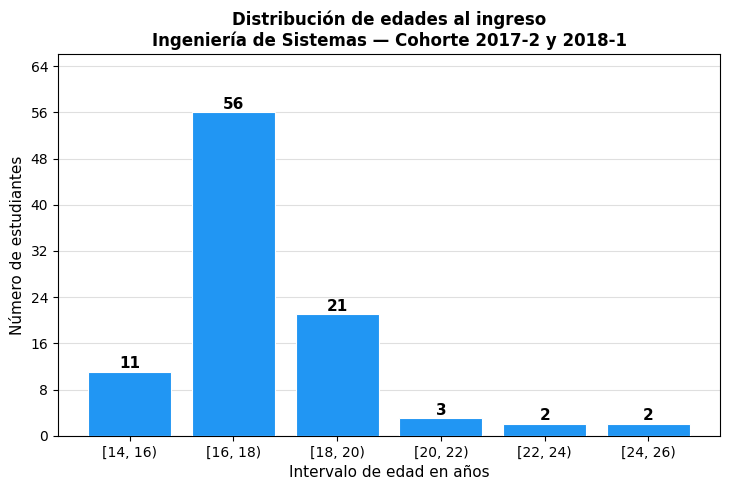

In [4]:
if not usar_intervalos:
    conteo = edades.value_counts().sort_index()
    x_labels = [str(v) for v in conteo.index]
    y_vals   = conteo.values
    titulo_eje = 'Edad en años al 01-jun-2017'
else:
    bins   = range(edades.min(), edades.max() + 3, 2)
    cuts   = pd.cut(edades, bins=list(bins), right=False)
    conteo = cuts.value_counts().sort_index()
    x_labels = [str(iv) for iv in conteo.index]
    y_vals   = conteo.values
    titulo_eje = 'Intervalo de edad en años'

fig, ax = plt.subplots(figsize=(max(7, len(x_labels) * 0.9 + 2), 5))

bars = ax.bar(x_labels, y_vals, color=COLOR_MAIN, edgecolor='white', linewidth=0.8, zorder=3)

for bar, val in zip(bars, y_vals):
    if val > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.15,
            str(val),
            ha='center', va='bottom', fontsize=11, fontweight='bold'
        )

ax.set_xlabel(titulo_eje, fontsize=11)
ax.set_ylabel('Número de estudiantes', fontsize=11)
ax.set_title(
    f'Distribución de edades al ingreso\nIngeniería de Sistemas — Cohorte {COHORTE}',
    fontsize=12, fontweight='bold'
)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_ylim(0, y_vals.max() * 1.18)
ax.grid(axis='y', alpha=0.4, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


## 4. Zona de residencia al momento del ingreso

El atributo `ZONA_LUGAR_RESIDENCIA` registra la zona declarada al momento de la admisión.
Valores: U = Urbana, R = Rural.

Zona de residencia al ingreso
  Urbana: 77 estudiantes  81.1%
  Rural: 18 estudiantes  18.9%
  Total: 95


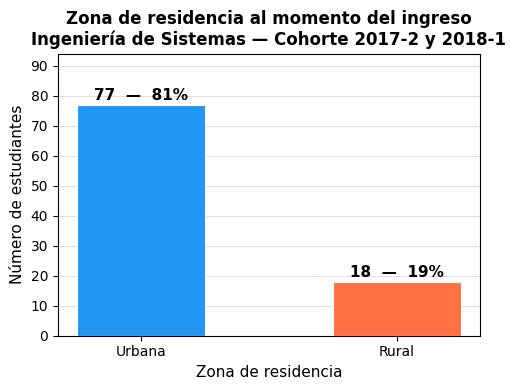

In [5]:
zona_map = {'U': 'Urbana', 'R': 'Rural'}
zona_vals = ing_car['ZONA_LUGAR_RESIDENCIA'].map(zona_map).fillna('Sin dato')
conteo_zona = zona_vals.value_counts()
# Garantizar orden: Urbana primero
orden_zona = [z for z in ['Urbana', 'Rural', 'Sin dato'] if z in conteo_zona.index]
conteo_zona = conteo_zona.reindex(orden_zona)

print('Zona de residencia al ingreso')
for zona, cnt in conteo_zona.items():
    pct = cnt / len(zona_vals) * 100
    print(f'  {zona}: {cnt} estudiantes  {pct:.1f}%')
print(f'  Total: {len(zona_vals)}')

colores_zona = [COLOR_MAIN if z == 'Urbana' else COLOR_ALT for z in conteo_zona.index]

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(conteo_zona.index, conteo_zona.values,
              color=colores_zona, edgecolor='white', linewidth=0.8, width=0.5, zorder=3)

for bar, val in zip(bars, conteo_zona.values):
    pct = val / len(zona_vals) * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f'{val}  —  {pct:.0f}%',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_ylabel('Número de estudiantes', fontsize=11)
ax.set_xlabel('Zona de residencia', fontsize=11)
ax.set_title(
    f'Zona de residencia al momento del ingreso\nIngeniería de Sistemas — Cohorte {COHORTE}',
    fontsize=12, fontweight='bold'
)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_ylim(0, conteo_zona.values.max() * 1.22)
ax.grid(axis='y', alpha=0.4, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


## 5. Ingresos del hogar

El atributo `INGRESOS` registra los ingresos anuales del hogar del estudiante en pesos colombianos COP.
Los valores se agrupan en rangos de millones para facilitar la lectura.

Ingresos anuales del hogar en millones COP
  Estudiantes con datos: 95
  Mínimo:  $3.0M
  Máximo:  $62.7M
  Mediana: $9.6M
  Media:   $14.4M

  0 – 5 millones: 4 estudiantes
  5 – 10 millones: 48 estudiantes
  10 – 15 millones: 14 estudiantes
  15 – 20 millones: 12 estudiantes
  20 – 30 millones: 9 estudiantes
  30 – 50 millones: 7 estudiantes


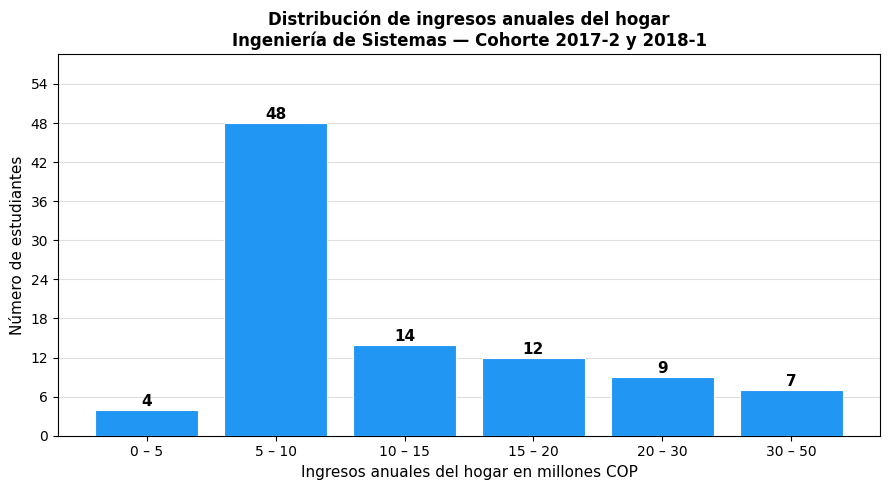

In [6]:
ingresos_M = ing_car['INGRESOS'].dropna() / 1_000_000  # en millones COP

bins_M = [0, 5, 10, 15, 20, 30, 50]
labels_ing = ['0 – 5', '5 – 10', '10 – 15', '15 – 20', '20 – 30', '30 – 50']
cortes = pd.cut(ingresos_M, bins=bins_M, labels=labels_ing, right=False)
conteo_ing = cortes.value_counts().sort_index()

print('Ingresos anuales del hogar en millones COP')
print(f'  Estudiantes con datos: {len(ingresos_M)}')
print(f'  Mínimo:  ${ingresos_M.min():.1f}M')
print(f'  Máximo:  ${ingresos_M.max():.1f}M')
print(f'  Mediana: ${ingresos_M.median():.1f}M')
print(f'  Media:   ${ingresos_M.mean():.1f}M')
print()
for rango, cnt in conteo_ing.items():
    print(f'  {rango} millones: {cnt} estudiantes')

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels_ing, conteo_ing.values,
              color=COLOR_MAIN, edgecolor='white', linewidth=0.8, zorder=3)

for bar, val in zip(bars, conteo_ing.values):
    if val > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.15,
            str(val),
            ha='center', va='bottom', fontsize=11, fontweight='bold'
        )

ax.set_xlabel('Ingresos anuales del hogar en millones COP', fontsize=11)
ax.set_ylabel('Número de estudiantes', fontsize=11)
ax.set_title(
    f'Distribución de ingresos anuales del hogar\nIngeniería de Sistemas — Cohorte {COHORTE}',
    fontsize=12, fontweight='bold'
)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_ylim(0, conteo_ing.values.max() * 1.22)
ax.grid(axis='y', alpha=0.4, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


## 6. Prueba Saber 11 — Identificación de formatos

El ICFES ha manejado dos formatos del examen Saber 11:

Formato antiguo hasta 2013: PBIO · PMAT · PFIL · PFIS · PQUI · PLEN · PING · PSOC

Formato nuevo desde 2014: PMATN · PINGN · PCRIN · PCIUN · PNATN

Ambos son mutuamente excluyentes en este dataset

In [7]:
has_old = (ing_car[COLS_OLD].fillna(0) > 0).any(axis=1)
has_new = (ing_car[COLS_NEW].fillna(0) > 0).any(axis=1)

ing_car['FORMATO_SABER'] = 'SIN_DATO'
ing_car.loc[has_old, 'FORMATO_SABER'] = 'ANTIGUO'
ing_car.loc[has_new, 'FORMATO_SABER'] = 'NUEVO'

print('Distribución de formatos Saber 11')
print(f'  Formato NUEVO:    {has_new.sum()} estudiantes')
print(f'  Formato ANTIGUO:  {has_old.sum()} estudiante')
print(f'  Sin datos:        {(~has_old & ~has_new).sum()}')
print(f'  Con ambos:        {(has_old & has_new).sum()}')


Distribución de formatos Saber 11
  Formato NUEVO:    94 estudiantes
  Formato ANTIGUO:  1 estudiante
  Sin datos:        0
  Con ambos:        0


## 7. Resultados Saber 11 — Formato Posterior a 2013

Componentes: Matemáticas · Inglés · Lectura Crítica · Sociales y Ciudadanas · Ciencias Naturales.
Escala: 0 a 500.

Estadísticas por componente — Formato Nuevo
       Matemáticas  Inglés  Lectura Crítica  Soc. y Ciudadanas  Ciencias Naturales
count        94.00   94.00            94.00              94.00               94.00
mean         65.62   63.10            62.72              62.34               63.91
std           5.20    8.63             6.35               6.74                5.98
min          56.00   45.00            49.00              45.00               47.00
25%          62.00   57.00            58.00              58.25               61.00
50%          65.00   63.00            63.00              63.00               64.00
75%          68.75   67.00            65.00              67.00               66.75
max          89.00   88.00           100.00              79.00              100.00


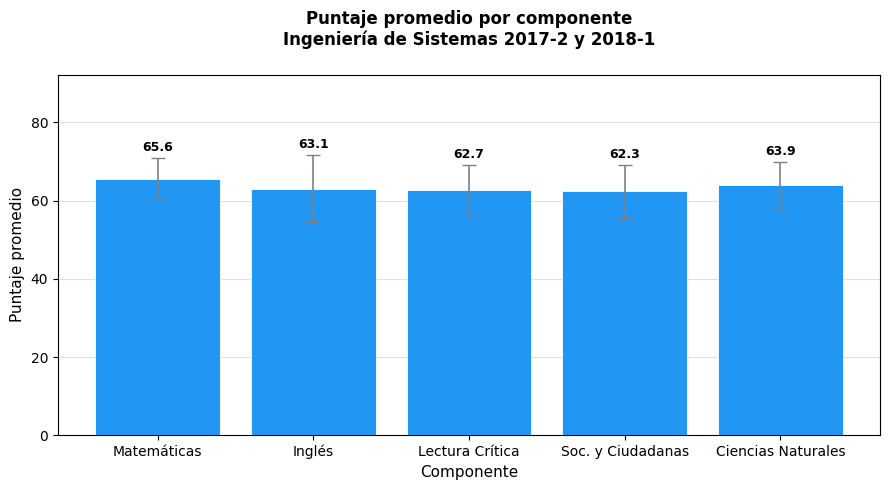

In [8]:
df_nuevo = ing_car[ing_car['FORMATO_SABER'] == 'NUEVO'].copy()

stats_new = df_nuevo[COLS_NEW].describe().round(2)
stats_new.columns = [LABELS_NEW[c] for c in COLS_NEW]
print('Estadísticas por componente — Formato Nuevo')
print(stats_new.to_string())

medias = df_nuevo[COLS_NEW].mean()
stds   = df_nuevo[COLS_NEW].std()
labels = [LABELS_NEW[c] for c in COLS_NEW]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    labels, medias,
    color=COLOR_MAIN, edgecolor='white', linewidth=0.6,
    yerr=stds, capsize=5,
    error_kw={'ecolor': 'gray', 'elinewidth': 1.2},
    zorder=3
)

for bar, media, std in zip(bars, medias, stds):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + std + 1,
        f'{media:.1f}',
        ha='center', va='bottom', fontsize=9, fontweight='bold'
    )

ax.set_ylim(0, medias.max() + stds.max() + 18)
ax.set_ylabel('Puntaje promedio', fontsize=11)
ax.set_xlabel('Componente', fontsize=11)
ax.set_title(
    f'Puntaje promedio por componente\n'
    f'Ingeniería de Sistemas {COHORTE}\n',
    fontsize=12, fontweight='bold'
)
ax.grid(axis='y', alpha=0.4, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


## 8. Resultados Saber 11 — Formato Antiguo

Puntaje calculado como promedio ponderado de 8 componentes. Escala: 0 a 100.
La cohorte tiene un solo estudiante con este formato; se muestra el registro puntual sin gráfica.

In [9]:
df_antiguo = ing_car[ing_car['FORMATO_SABER'] == 'ANTIGUO'].copy()

print(f'Estudiantes con formato antiguo: {len(df_antiguo)}')

if len(df_antiguo) > 0:
    df_antiguo['PUNTAJE_PONDERADO'] = df_antiguo.apply(
        lambda row: sum(
            row[c] * PESOS_OLD[c] for c in COLS_OLD if pd.notna(row[c]) and row[c] > 0
        ) / 13,
        axis=1
    ).round(2)
    print('Puntajes por componente y puntaje ponderado')
    print(df_antiguo[COLS_OLD + ['PUNTAJE_PONDERADO']].to_string(index=False))
else:
    print('No hay estudiantes con formato antiguo en esta cohorte.')

Estudiantes con formato antiguo: 1
Puntajes por componente y puntaje ponderado
 PBIO  PMAT  PFIL  PFIS  PQUI  PLEN  PING  PSOC  PUNTAJE_PONDERADO
 57.0 122.0  62.0  60.0  67.0  54.0  57.0  53.0              72.08


## 9. Estrato socioeconómico y relación con el puntaje Saber 11

Se muestran dos figuras:
- Distribución de estudiantes por estrato.
- Boxplot del puntaje total Saber 11 por estrato, usando únicamente los 46 estudiantes con formato nuevo. Los puntos superpuestos representan estudiantes individuales.

El estudiante con formato antiguo se excluye del boxplot porque la escala de ese formato no es comparable con la del formato nuevo.

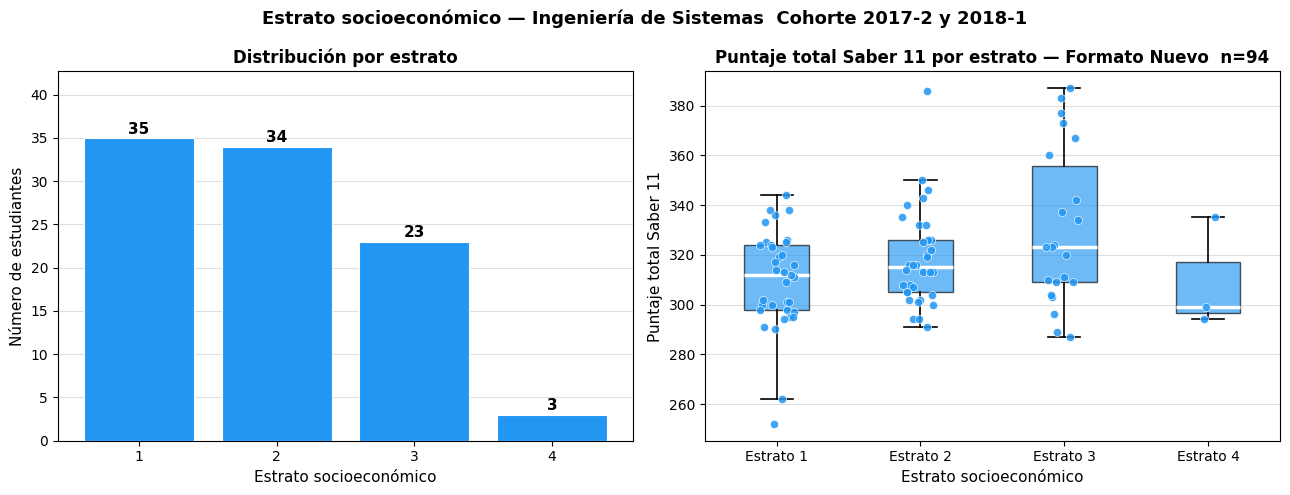

Resumen puntaje total ICFES por estrato
                count   mean   std    min    50%    max
ESTRATO_ACTUAL                                         
1                35.0  309.8  19.9  252.0  312.0  344.0
2                34.0  318.4  19.4  291.0  315.0  386.0
3                22.0  330.4  31.3  287.0  323.0  387.0
4                 3.0  309.3  22.4  294.0  299.0  335.0


In [10]:
conteo_est = ing_car['ESTRATO_ACTUAL'].value_counts().sort_index()

# Puntaje total formato nuevo por estrato
df_nuevo_est = df_nuevo.copy()
df_nuevo_est['TOTAL_ICFES'] = df_nuevo_est[COLS_NEW].sum(axis=1)

estratos = sorted(df_nuevo_est['ESTRATO_ACTUAL'].dropna().unique().astype(int))
datos_por_estrato = [
    df_nuevo_est[df_nuevo_est['ESTRATO_ACTUAL'] == e]['TOTAL_ICFES'].values
    for e in estratos
]

rng = np.random.default_rng(42)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- Subplot 1: distribución por estrato ---
bars1 = ax1.bar(conteo_est.index, conteo_est.values,
                color=COLOR_MAIN, edgecolor='white', linewidth=0.8, zorder=3)
for bar, val in zip(bars1, conteo_est.values):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.15,
        str(val),
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
ax1.set_xlabel('Estrato socioeconómico', fontsize=11)
ax1.set_ylabel('Número de estudiantes', fontsize=11)
ax1.set_title('Distribución por estrato', fontsize=12, fontweight='bold')
ax1.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax1.set_ylim(0, conteo_est.values.max() * 1.22)
ax1.set_xticks(estratos)
ax1.grid(axis='y', alpha=0.4, zorder=0)
ax1.set_axisbelow(True)

# --- Subplot 2: boxplot puntaje ICFES por estrato ---
bp = ax2.boxplot(
    datos_por_estrato,
    patch_artist=True,
    medianprops={'color': 'white', 'linewidth': 2.5},
    whiskerprops={'linewidth': 1.2},
    capprops={'linewidth': 1.2},
    flierprops={'marker': ''},   # ocultar outliers del boxplot; se muestran como scatter
)
for patch in bp['boxes']:
    patch.set_facecolor(COLOR_MAIN)
    patch.set_alpha(0.65)

for i, datos in enumerate(datos_por_estrato, 1):
    jitter = rng.uniform(-0.13, 0.13, size=len(datos))
    ax2.scatter(
        [i + j for j in jitter], datos,
        color=COLOR_MAIN, edgecolors='white', linewidths=0.5,
        s=35, alpha=0.85, zorder=5
    )

ax2.set_xticks(range(1, len(estratos) + 1))
ax2.set_xticklabels([f'Estrato {e}' for e in estratos])
ax2.set_ylabel('Puntaje total Saber 11', fontsize=11)
ax2.set_xlabel('Estrato socioeconómico', fontsize=11)
ax2.set_title(
    f'Puntaje total Saber 11 por estrato — Formato Nuevo  n={len(df_nuevo_est)}',
    fontsize=12, fontweight='bold'
)
ax2.grid(axis='y', alpha=0.4, zorder=0)
ax2.set_axisbelow(True)

plt.suptitle(
    f'Estrato socioeconómico — Ingeniería de Sistemas  Cohorte {COHORTE}',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

print('Resumen puntaje total ICFES por estrato')
resumen = df_nuevo_est.groupby('ESTRATO_ACTUAL')['TOTAL_ICFES'].describe().round(1)
print(resumen[['count', 'mean', 'std', 'min', '50%', 'max']].to_string())


## 10. Tiempo hasta la graduación por estudiante

Para cada estudiante en el historial se identifican tres casos:
- Con registro MATRICULADO y GRADUADO: se calcula la diferencia en años entre el primer semestre matriculado y el semestre de grado. Cada semestre equivale a 0.5 años.
- Con registro MATRICULADO pero sin GRADUADO: clasificado como No se graduó.
- Sin ningún registro MATRICULADO: también clasificado como No se graduó.

In [11]:
def periodo_a_float(p: str) -> float:
    """Convierte 'AAAA-S' a flotante: 2017-2 → 2017.5"""
    anio, sem = p.strip().split('-')
    return int(anio) + (int(sem) - 1) * 0.5


ing_he['periodo_num']   = ing_he['PERIODO_ESTADO'].astype(str).apply(periodo_a_float)

resultados = []
for codigo, grupo in ing_he.groupby('CODIGO_INST'):
    mat = grupo[grupo['estado_limpio'] == 'MATRICULADO']
    grd = grupo[grupo['estado_limpio'] == 'GRADUADO']

    if mat.empty:
        resultados.append({'CODIGO_INST': codigo, 'anios': None, 'categoria': 'No se graduó'})
        continue

    primer_mat = mat['periodo_num'].min()
    if not grd.empty:
        anios = round(grd['periodo_num'].iloc[0] - primer_mat, 1)
        resultados.append({'CODIGO_INST': codigo, 'anios': anios, 'categoria': f'{anios:.1f} años'})
    else:
        resultados.append({'CODIGO_INST': codigo, 'anios': None, 'categoria': 'No se graduó'})

df_res = pd.DataFrame(resultados)

print(f'Estudiantes en el análisis: {len(df_res)}')
print(f'Graduados:        {df_res["anios"].notna().sum()}')
print(f'No se graduaron:  {(df_res["categoria"] == "No se graduó").sum()}')
print()
print(df_res['categoria'].value_counts().sort_index().to_string())


Estudiantes en el análisis: 97
Graduados:        35
No se graduaron:  62

categoria
3.5 años         2
4.0 años         2
4.5 años         1
5.0 años         5
5.5 años        11
6.0 años         9
6.5 años         2
7.0 años         2
7.5 años         1
No se graduó    62


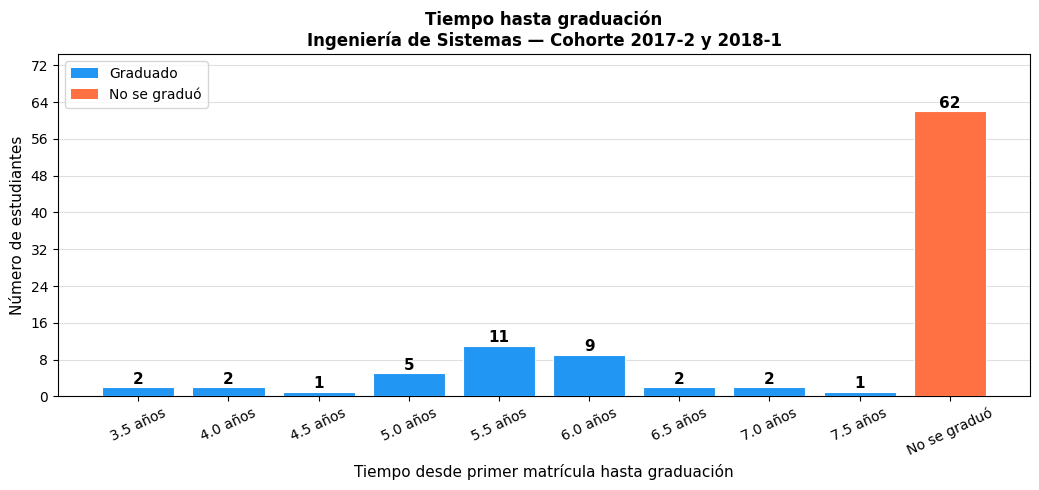

In [12]:
cats_tiempo = sorted(
    df_res[df_res['anios'].notna()]['categoria'].unique(),
    key=lambda x: float(x.split()[0])
)
orden = cats_tiempo + ['No se graduó']
conteo_grad = df_res['categoria'].value_counts().reindex(orden, fill_value=0)
colores = [COLOR_MAIN if c != 'No se graduó' else COLOR_ALT for c in conteo_grad.index]

fig, ax = plt.subplots(figsize=(max(8, len(orden) * 0.85 + 2), 5))

bars = ax.bar(conteo_grad.index, conteo_grad.values,
              color=colores, edgecolor='white', linewidth=0.8, zorder=3)

for bar, val in zip(bars, conteo_grad.values):
    if val > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.12,
            str(val),
            ha='center', va='bottom', fontsize=11, fontweight='bold'
        )

ax.set_xlabel('Tiempo desde primer matrícula hasta graduación', fontsize=11)
ax.set_ylabel('Número de estudiantes', fontsize=11)
ax.set_title(
    f'Tiempo hasta graduación\nIngeniería de Sistemas — Cohorte {COHORTE}',
    fontsize=12, fontweight='bold'
)
ax.tick_params(axis='x', rotation=25)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_ylim(0, conteo_grad.values.max() * 1.2)
ax.grid(axis='y', alpha=0.4, zorder=0)
ax.set_axisbelow(True)

legend_elements = [
    Patch(facecolor=COLOR_MAIN, label='Graduado'),
    Patch(facecolor=COLOR_ALT,  label='No se graduó'),
]
ax.legend(handles=legend_elements, fontsize=10, loc='upper left')

plt.tight_layout()
plt.show()


## 11. Causa de retiro — No graduados
Para cada estudiante que no se graduó se identifica cuál fue la última etiqueta de estado registrada en el historial.
Esto permite entender la razón más frecuente con la que los estudiantes abandonaron el programa.

Estudiantes no graduados: 62

Última etiqueta registrada por estudiante
  MATRICULADO: 1
  RETIRO DEFINITIVO DEL PROGRAMA CON BAJO RENDIMIENTO: 1
  RETIRO POR NO RENOVACION DE MATRICULA: 4
  RETIRO DEFINITIVO VOLUNTARIO DEL PROGRAMA: 9
  RETIRADO BR: 11
  NO REALIZO PAGO: 36


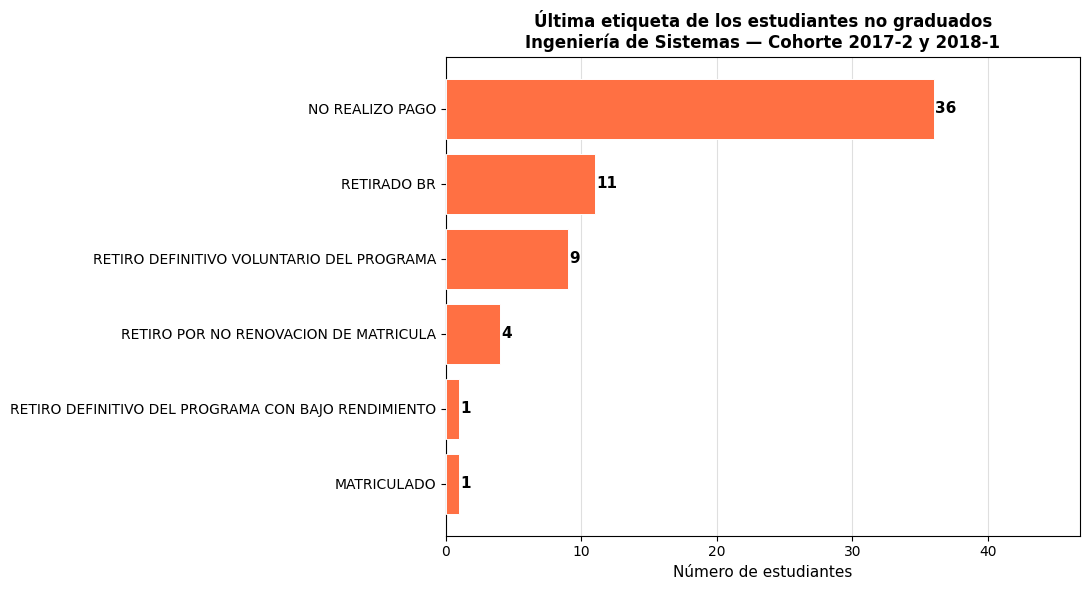

In [13]:
no_grad_codes = set(
    df_res[df_res['categoria'] == 'No se graduó']['CODIGO_INST'].astype(str)
)

df_ng = ing_he[ing_he['CODIGO_INST'].astype(str).isin(no_grad_codes)].copy()

# Último registro por periodo para cada estudiante
df_ultima = (
    df_ng.sort_values('periodo_num')
    .groupby('CODIGO_INST')
    .last()
    .reset_index()
)

conteo_ultima = df_ultima['estado_limpio'].value_counts().sort_values(ascending=True)

print(f'Estudiantes no graduados: {len(df_ultima)}')
print()
print('Última etiqueta registrada por estudiante')
for etiqueta, cnt in conteo_ultima.items():
    print(f'  {etiqueta}: {cnt}')

# Gráfica horizontal
fig, ax = plt.subplots(figsize=(11, max(4, len(conteo_ultima) * 0.75 + 1.5)))

bars = ax.barh(
    conteo_ultima.index, conteo_ultima.values,
    color=COLOR_ALT, edgecolor='white', linewidth=0.7, zorder=3
)

for bar, val in zip(bars, conteo_ultima.values):
    ax.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        str(val),
        va='center', ha='left', fontsize=11, fontweight='bold'
    )

ax.set_xlabel('Número de estudiantes', fontsize=11)
ax.set_title(
    f'Última etiqueta de los estudiantes no graduados\n'
    f'Ingeniería de Sistemas — Cohorte {COHORTE}',
    fontsize=12, fontweight='bold'
)
ax.set_xlim(0, conteo_ultima.values.max() * 1.3)
ax.grid(axis='x', alpha=0.4, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

RETIRADO BR, RETIRO DEFINITIVO DEL PROGRAMA CON BAJO R. significan una causa muy similar de bajo rendimiento academico.

## 12. Duración en la carrera de los estudiantes no graduados

Se cuenta cuántos períodos académicos tuvo cada estudiante no graduado en un estado diferente a **NO REALIZO PAGO**.
Esto refleja cuánto tiempo estuvieron activos en la carrera antes de retirarse, ignorando los semestres en que simplemente no pagaron matrícula.

Estudiantes no graduados: 62
  Con al menos un período activo: 51
  Solo con estado NO REALIZO PAGO: 11

Distribución de períodos académicos activos
  0 períodos — solo NO REALIZO PAGO: 11 estudiantes
  1 período: 25 estudiantes
  2 períodos: 17 estudiantes
  3 períodos: 2 estudiantes
  4 períodos: 3 estudiantes
  7 períodos: 2 estudiantes
  9 períodos: 2 estudiantes

  Mínimo:  0 período(s)
  Máximo:  9 período(s)
  Mediana: 1.0 período(s)
  Media:   1.8 período(s)


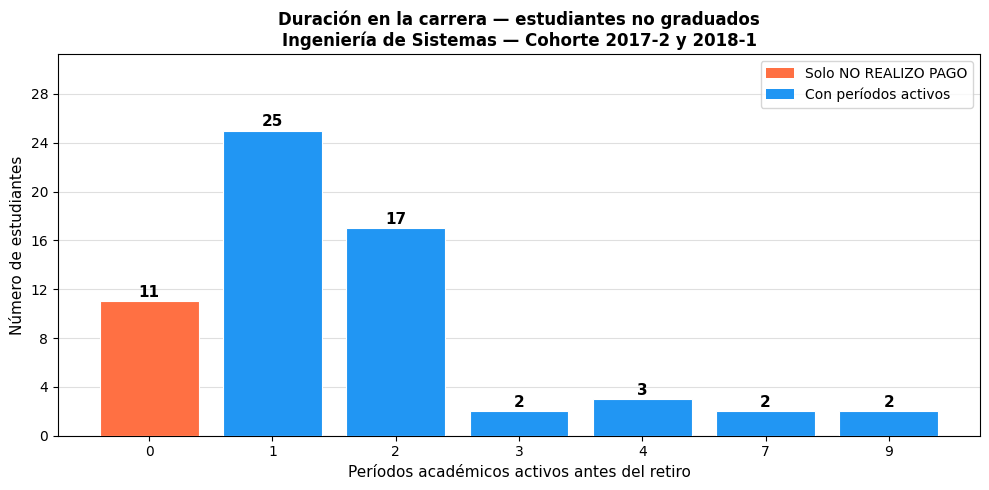

In [14]:
ESTADOS_INACTIVOS = ['NO REALIZO PAGO']

df_ng_activo = ing_he[
    (ing_he['CODIGO_INST'].astype(str).isin(no_grad_codes)) &
    (~ing_he['estado_limpio'].isin(ESTADOS_INACTIVOS))
].copy()

periodos_activos = (
    df_ng_activo.groupby('CODIGO_INST')['PERIODO_ESTADO']
    .nunique()
    .reset_index()
    .rename(columns={'PERIODO_ESTADO': 'periodos_activos'})
)

# Incluir los estudiantes que solo tienen NO REALIZO PAGO → 0 períodos activos
# Normalizar tipo: CODIGO_INST puede ser int o str según el dataset
todos_ng = pd.DataFrame({'CODIGO_INST': list(no_grad_codes)})
todos_ng['CODIGO_INST'] = todos_ng['CODIGO_INST'].astype(str)
periodos_activos['CODIGO_INST'] = periodos_activos['CODIGO_INST'].astype(str)
periodos_por_est = (
    todos_ng.merge(periodos_activos, on='CODIGO_INST', how='left')
    .fillna({'periodos_activos': 0})
    .astype({'periodos_activos': int})
)

conteo_periodos = periodos_por_est['periodos_activos'].value_counts().sort_index()

n_solo_nrp = (periodos_por_est['periodos_activos'] == 0).sum()

print(f'Estudiantes no graduados: {len(periodos_por_est)}')
print(f'  Con al menos un período activo: {(periodos_por_est["periodos_activos"] > 0).sum()}')
print(f'  Solo con estado NO REALIZO PAGO: {n_solo_nrp}')
print()
print('Distribución de períodos académicos activos')
for n_per, cnt in conteo_periodos.items():
    semestres = 'período' if n_per == 1 else 'períodos'
    label = f'{n_per} {semestres}' if n_per > 0 else '0 períodos — solo NO REALIZO PAGO'
    print(f'  {label}: {cnt} estudiante{"s" if cnt > 1 else ""}')
print()
print(f'  Mínimo:  {periodos_por_est["periodos_activos"].min()} período(s)')
print(f'  Máximo:  {periodos_por_est["periodos_activos"].max()} período(s)')
print(f'  Mediana: {periodos_por_est["periodos_activos"].median():.1f} período(s)')
print(f'  Media:   {periodos_por_est["periodos_activos"].mean():.1f} período(s)')

# Gráfica
fig, ax = plt.subplots(figsize=(10, 5))

x_vals = conteo_periodos.index.tolist()
colores_bar = [COLOR_ALT if x == 0 else COLOR_MAIN for x in x_vals]
bars = ax.bar(
    [str(x) for x in x_vals], conteo_periodos.values,
    color=colores_bar, edgecolor='white', linewidth=0.8, zorder=3
)

for bar, val in zip(bars, conteo_periodos.values):
    if val > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.1,
            str(val),
            ha='center', va='bottom', fontsize=11, fontweight='bold'
        )

ax.set_xlabel('Períodos académicos activos antes del retiro', fontsize=11)
ax.set_ylabel('Número de estudiantes', fontsize=11)
ax.set_title(
    f'Duración en la carrera — estudiantes no graduados\n'
    f'Ingeniería de Sistemas — Cohorte {COHORTE}',
    fontsize=12, fontweight='bold'
)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_ylim(0, conteo_periodos.values.max() * 1.25)
ax.grid(axis='y', alpha=0.4, zorder=0)
ax.set_axisbelow(True)

legend_elements = [
    Patch(facecolor=COLOR_ALT,  label='Solo NO REALIZO PAGO'),
    Patch(facecolor=COLOR_MAIN, label='Con períodos activos'),
]
ax.legend(handles=legend_elements, fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()


## 13. Habilitaciones por materia

Para cada registro con `OBSERVACION = 'H'` en el dataset `detalle_materias` se clasifica la habilitación como:
- **Exitosa**: `DEFINITIVA ≥ 3.0`
- **No exitosa**: `DEFINITIVA < 3.0`

Se muestra la distribución por materia en una gráfica de barras apiladas.

Registros detalle_materias INGENIERIA DE SISTEMAS 2017-2 y 2018-1: 2725
Estudiantes únicos: 90

Total habilitaciones: 110
  Exitosas  (≥ 3.0): 68
  No exitosas (< 3.0): 42

resultado                      Exitosa  No exitosa
MATERIA                                           
MATEMATICA DISCRETA                 26           5
ALGEBRA LINEAL                      20           5
MATEMATICAS II                       3          12
MATEMATICAS I                        6           8
PROCESOS COMUNICATIVOS              10           0
PENSAMIENTO LOGICO MATEMATICO        2           3
MATEMATICAS III                      0           3
MATEMATICAS ESPECIALES               0           3
PROBABILIDAD Y ESTADISTICA           1           1
CALCULO DIFERENCIAL                  0           1
MATEMÁTICAS ESPECIALES               0           1


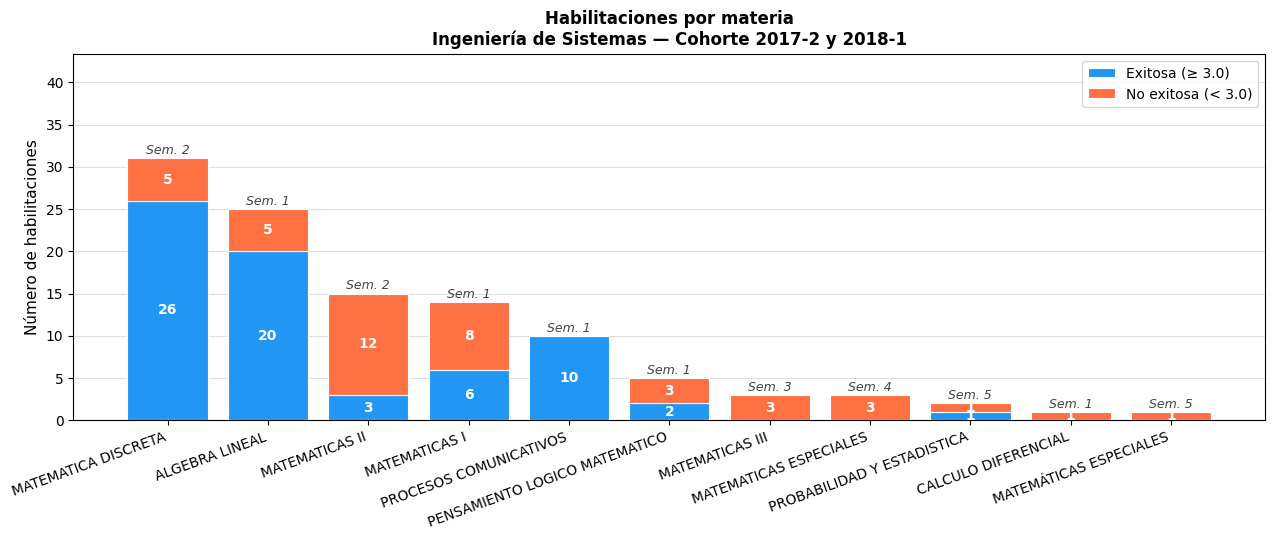

In [15]:
# Cargar dataset detalle_materias y filtrar cohorte
df_mat = pd.read_excel(os.path.join(DATA_DIR, 'detalle_materias.xlsx'))

ing_mat = df_mat[
    (df_mat['PROGRAMA'].str.strip().str.upper() == PROGRAMA) &
    (df_mat['COHORTE'].astype(str).str.strip() .isin(COHORTES))
].copy()

print(f'Registros detalle_materias {PROGRAMA} {COHORTE}: {len(ing_mat)}')
print(f'Estudiantes únicos: {ing_mat["CODIGO_INST"].nunique()}')

# Filtrar habilitaciones (OBSERVACION = 'H')
hab = ing_mat[ing_mat['OBSERVACION'].str.strip().str.upper() == 'H'].copy()
hab['resultado'] = hab['DEFINITIVA'].apply(
    lambda x: 'Exitosa' if pd.notna(x) and x >= 3.0 else 'No exitosa'
)

n_exitosas   = (hab['resultado'] == 'Exitosa').sum()
n_no_exitosa = (hab['resultado'] == 'No exitosa').sum()

print(f'\nTotal habilitaciones: {len(hab)}')
print(f'  Exitosas  (≥ 3.0): {n_exitosas}')
print(f'  No exitosas (< 3.0): {n_no_exitosa}')

# Semestre de cada materia (único por materia en este dataset)
semestre_mat = (
    hab.groupby('MATERIA')['SEMESTRE']
    .agg(lambda x: int(x.mode()[0]))
)

# Pivot: filas = MATERIA, columnas = Exitosa | No exitosa
hab_pivot = (
    hab.groupby(['MATERIA', 'resultado'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=['Exitosa', 'No exitosa'], fill_value=0)
)
hab_pivot = (
    hab_pivot
    .assign(total=hab_pivot.sum(axis=1))
    .sort_values('total', ascending=False)
    .drop(columns='total')
)

print()
print(hab_pivot.to_string())

# Gráfica de barras apiladas
fig, ax = plt.subplots(figsize=(13, 5.5))

x_pos = list(range(len(hab_pivot)))
b1 = ax.bar(x_pos, hab_pivot['Exitosa'],
            color=COLOR_MAIN, label='Exitosa (≥ 3.0)',
            edgecolor='white', linewidth=0.8, zorder=3)
b2 = ax.bar(x_pos, hab_pivot['No exitosa'],
            bottom=hab_pivot['Exitosa'],
            color=COLOR_ALT, label='No exitosa (< 3.0)',
            edgecolor='white', linewidth=0.8, zorder=3)

# Etiquetas dentro de cada segmento
for i, (materia, row) in enumerate(hab_pivot.iterrows()):
    if row['Exitosa'] > 0:
        ax.text(i, row['Exitosa'] / 2, str(row['Exitosa']),
                ha='center', va='center', fontsize=10,
                fontweight='bold', color='white')
    if row['No exitosa'] > 0:
        ax.text(i, row['Exitosa'] + row['No exitosa'] / 2,
                str(row['No exitosa']),
                ha='center', va='center', fontsize=10,
                fontweight='bold', color='white')

# Etiqueta de semestre encima de cada barra
total_bar = hab_pivot.sum(axis=1)
for i, materia in enumerate(hab_pivot.index):
    sem = semestre_mat.get(materia, '?')
    ax.text(i, total_bar[materia] + 0.15,
            f'Sem. {sem}',
            ha='center', va='bottom', fontsize=9,
            color='#444444', fontstyle='italic')

ax.set_xticks(x_pos)
ax.set_xticklabels(hab_pivot.index, rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Número de habilitaciones', fontsize=11)
ax.set_title(
    f'Habilitaciones por materia\nIngeniería de Sistemas — Cohorte {COHORTE}',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=10, loc='upper right')
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.set_ylim(0, hab_pivot.sum(axis=1).max() * 1.4)
ax.grid(axis='y', alpha=0.4, zorder=0)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


## 14. Ranking de materias por promedio de nota definitiva

Para cada combinación estudiante-materia se toma la **nota más alta** en caso de existir múltiples registros.
Luego se calcula el promedio por materia y se listan las 5 con promedio más alto y las 5 con promedio más bajo.

Total materias con al menos un registro válido: 98
Materias excluidas por muestra insuficiente (N ≤ 5): 40

  Materias excluidas:
    TRABAJO DE GRADO 1                            promedio=4.88  N=4
    ARQUITECTURA EMPRESARIAL                      promedio=4.73  N=4
    CURSO 3 PROFUNDIZACIÓN                        promedio=4.65  N=4
    OSCILACIONES Y ONDAS                          promedio=4.35  N=4
    SEGURIDAD DE LA INFORMACIÓN                   promedio=4.32  N=4
    ELECTIVA PROFESIONAL 3                        promedio=4.32  N=4
    TRABAJO DE GRADO 2                            promedio=4.30  N=4
    FORMULACIÓN Y GESTIÓN DE PROYECTOS            promedio=4.22  N=4
    ELECTIVA COMPLEMENTARIA                       promedio=4.22  N=4
    ELECTIVA PROFESIONAL 4                        promedio=4.20  N=4
    ELECTIVA PROFESIONAL 5                        promedio=4.15  N=4
    ELECTIVA PROFESIONAL 1                        promedio=4.12  N=4
    ELECTIVA PROFESIONAL 2                

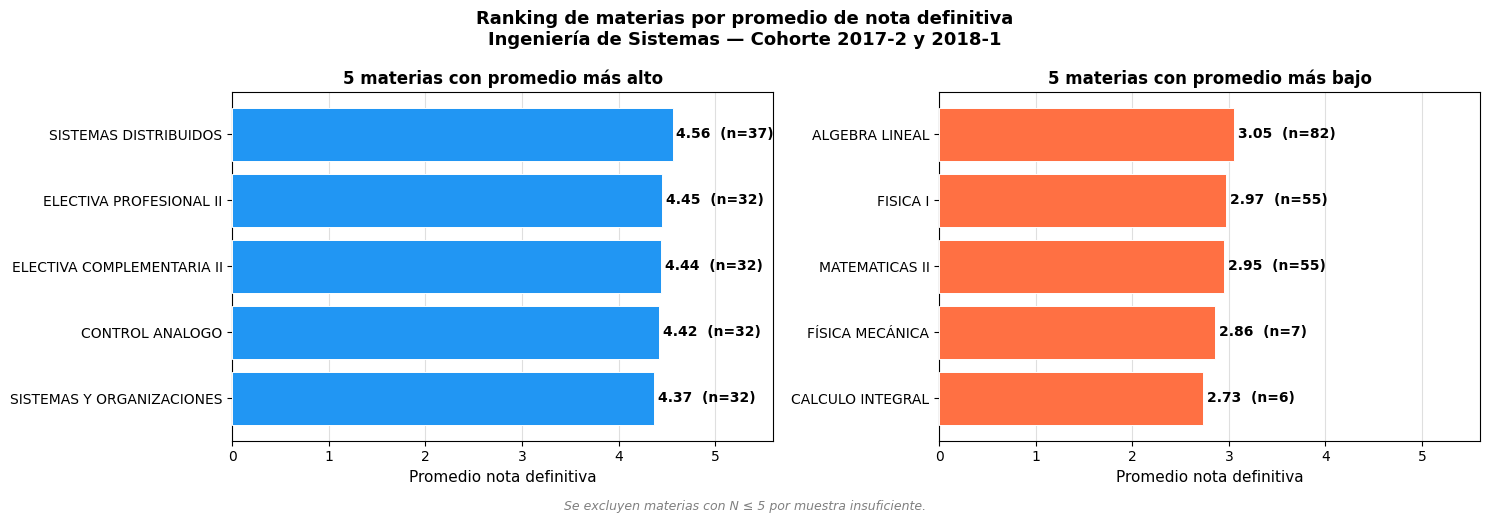

In [16]:
# Mejor nota por estudiante-materia (cuando hay más de un registro, se toma la más alta)
mejor_nota = (
    ing_mat.dropna(subset=['DEFINITIVA'])
    .groupby(['CODIGO_INST', 'MATERIA'])['DEFINITIVA']
    .max()
    .reset_index()
)

prom_mat = (
    mejor_nota.groupby('MATERIA')['DEFINITIVA']
    .agg(promedio='mean', n_estudiantes='count')
    .round(2)
    .reset_index()
    .sort_values('promedio', ascending=False)
    .reset_index(drop=True)
)

# Excluir materias con menos de 6 estudiantes (muestra insuficiente)
N_MIN = 5
excluidas = prom_mat[prom_mat['n_estudiantes'] <= N_MIN].copy()
prom_mat_filtrado = prom_mat[prom_mat['n_estudiantes'] > N_MIN].reset_index(drop=True)

print(f'Total materias con al menos un registro válido: {len(prom_mat)}')
print(f'Materias excluidas por muestra insuficiente (N ≤ {N_MIN}): {len(excluidas)}')
if len(excluidas) > 0:
    print()
    print('  Materias excluidas:')
    for _, row in excluidas.iterrows():
        print(f'    {row["MATERIA"]:<45} promedio={row["promedio"]:.2f}  N={row["n_estudiantes"]}')
    print(f'  → Se requieren al menos {N_MIN+1} estudiantes para que el promedio sea representativo.')

print()
print(f'Materias incluidas en el ranking: {len(prom_mat_filtrado)}')

top5 = prom_mat_filtrado.head(5).copy()
bot5 = prom_mat_filtrado.tail(5).copy()

print()
print('Top 5 — promedio más alto (nota máxima por estudiante, N > 5)')
print(top5.rename(columns={'promedio': 'Promedio', 'n_estudiantes': 'N'}).to_string(index=False))
print()
print('Top 5 — promedio más bajo (nota máxima por estudiante, N > 5)')
print(bot5.rename(columns={'promedio': 'Promedio', 'n_estudiantes': 'N'}).to_string(index=False))

# Gráficas horizontales
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

def plot_ranking(ax, df, color, titulo):
    df = df.reset_index(drop=True)
    ax.barh(df['MATERIA'], df['promedio'],
            color=color, edgecolor='white', linewidth=0.7, zorder=3)
    for _, row in df.iterrows():
        ax.text(
            row['promedio'] + 0.04,
            row['MATERIA'],
            f"{row['promedio']:.2f}  (n={row['n_estudiantes']})",
            va='center', fontsize=10, fontweight='bold'
        )
    ax.invert_yaxis()
    ax.set_xlim(0, 5.6)
    ax.set_xlabel('Promedio nota definitiva', fontsize=11)
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)

plot_ranking(ax1, top5, COLOR_MAIN, '5 materias con promedio más alto')
plot_ranking(ax2, bot5, COLOR_ALT,  '5 materias con promedio más bajo')

nota_excl = f'Se excluyen materias con N ≤ {N_MIN} por muestra insuficiente.'
fig.text(0.5, -0.02, nota_excl, ha='center', fontsize=9, color='gray', fontstyle='italic')

plt.suptitle(
    f'Ranking de materias por promedio de nota definitiva\n'
    f'Ingeniería de Sistemas — Cohorte {COHORTE}',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()


Los promedios bajos en varias materias de Ciencias Basicas apuntan a la cantidad de estudiantes que no continuaron sus estudios despues de perder el curso, por tanto no poseen un registro de nota mas alto para ser tomado en cuenta.